In [23]:
import pandas as pd
import numpy as np

import statsmodels.api as sm

import matplotlib.pyplot as plt


In [24]:

#### Load Data
data = pd.read_csv('precipitation_mm.csv', parse_dates=True, index_col=0)

threshold = 1.0
data['rain'] = (data['precipitation_mm'] >= threshold).astype(float)
data['doy'] = data.index.dayofyear

In [32]:

data['sin_doy'] = np.sin(2 * np.pi * data['doy'] / 365.25)
data['cos_doy'] = np.cos(2 * np.pi * data['doy'] / 365.25)
data['sin_doy2'] = np.sin(4 * np.pi * data['doy'] / 365.25)
data['cos_doy2'] = np.cos(4 * np.pi * data['doy'] / 365.25)
data['rain_lag1'] = data['rain'].shift(1)

model_data = data.dropna(subset=['rain_lag1'])

X = sm.add_constant(model_data[['rain_lag1', 'sin_doy', 'cos_doy']])
y = model_data['rain']

logit_model = sm.Logit(y, X).fit()
print(logit_model.summary())

Optimization terminated successfully.
         Current function value: 0.586545
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                   rain   No. Observations:                27908
Model:                          Logit   Df Residuals:                    27904
Method:                           MLE   Df Model:                            3
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.09853
Time:                        13:41:39   Log-Likelihood:                -16369.
converged:                       True   LL-Null:                       -18158.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2101      0.018    -68.112      0.000      -1.245      -1.175
rain_lag1      1.5351      0.

In [26]:
def simulate_logistic(model, doy_array, initial_state, seed):
    rng = np.random.default_rng(seed)
    length = len(doy_array)
    states = np.zeros(length, dtype=int)
    states[0] = initial_state
    c = model.params

    for t in range(1, length):
        sin_t = np.sin(2 * np.pi * doy_array[t] / 365.25)
        cos_t = np.cos(2 * np.pi * doy_array[t] / 365.25)
        linpred = c['const'] + c['rain_lag1'] * states[t-1] + c['sin_doy'] * sin_t + c['cos_doy'] * cos_t
        p = 1 / (1 + np.exp(-linpred))
        states[t] = rng.binomial(1, p)

    return states


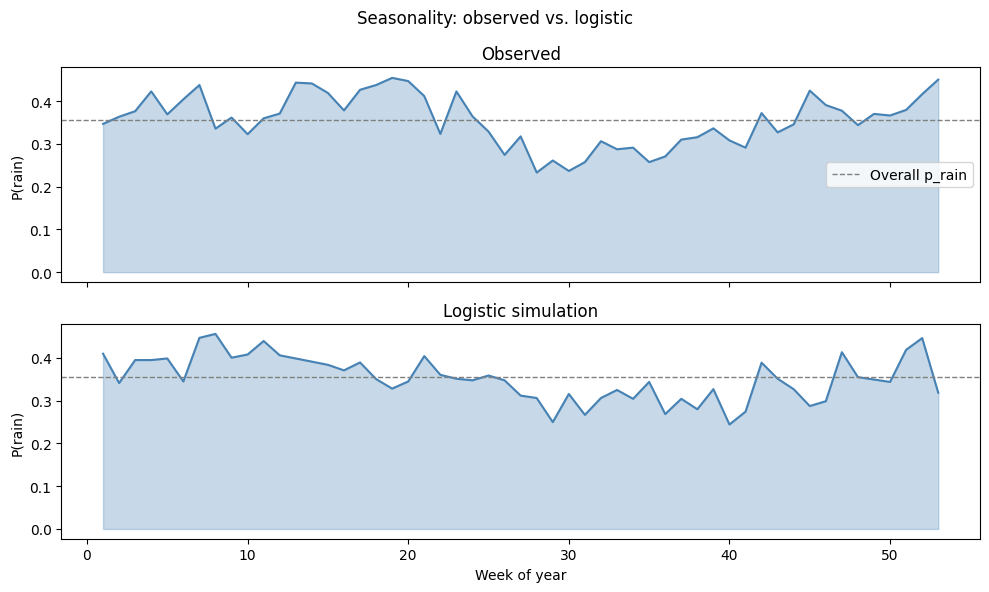

In [27]:
logistic_sim = simulate_logistic(logit_model, data['doy'].values, initial_state=0, seed=42)

logistic_df = pd.DataFrame({'rain': logistic_sim}, index=data.index)
logistic_df['week'] = data.index.isocalendar().week
data['week'] = data.index.isocalendar().week

weekly_observed = data.groupby('week')['rain'].mean()
weekly_logistic = logistic_df.groupby('week')['rain'].mean()

p_rain = data['rain'].mean()

fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
color = 'steelblue'

axes[0].plot(weekly_observed.index, weekly_observed.values, color=color, linewidth=1.5)
axes[0].fill_between(weekly_observed.index, weekly_observed.values, color=color, alpha=0.3)
axes[0].axhline(p_rain, color='gray', linestyle='--', linewidth=1, label='Overall p_rain')
axes[0].set_ylabel('P(rain)')
axes[0].set_title('Observed')
axes[0].legend()

axes[1].plot(weekly_logistic.index, weekly_logistic.values, color=color, linewidth=1.5)
axes[1].fill_between(weekly_logistic.index, weekly_logistic.values, color=color, alpha=0.3)
axes[1].axhline(p_rain, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel('P(rain)')
axes[1].set_xlabel('Week of year')
axes[1].set_title('Logistic simulation')

fig.suptitle('Seasonality: observed vs. logistic')
plt.tight_layout()
plt.show()

In [28]:
n_sims = 50
all_sims = np.array([simulate_logistic(logit_model, data['doy'].values, initial_state=0, seed=s) for s in range(n_sims)])

logistic_df_avg = pd.DataFrame({'rain': all_sims.mean(axis=0)}, index=data.index)
logistic_df_avg['week'] = data.index.isocalendar().week
weekly_logistic_avg = logistic_df_avg.groupby('week')['rain'].mean()

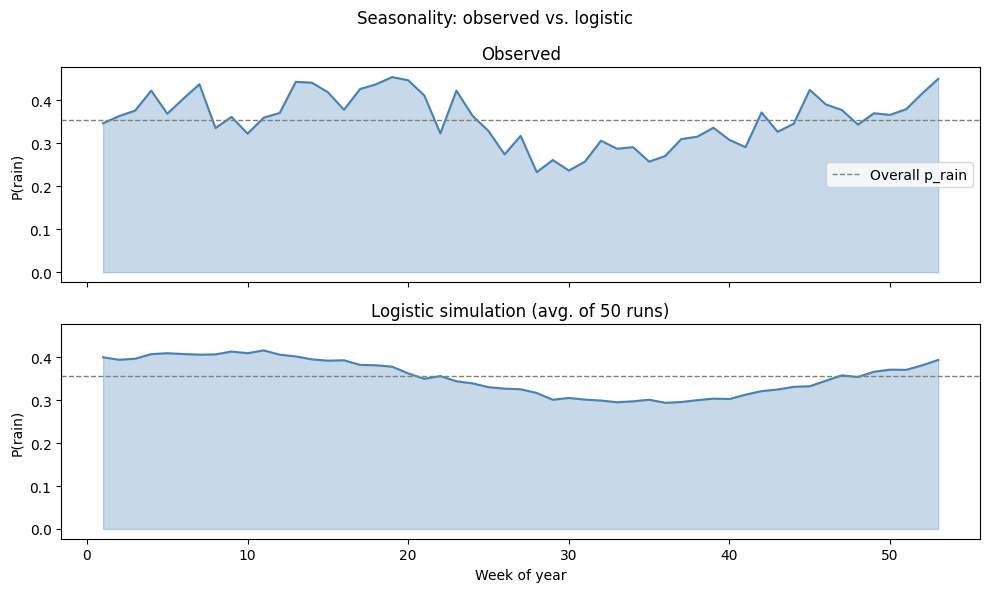

In [29]:
fig, axes = plt.subplots(2, 1, figsize=(10, 6), sharex=True, sharey=True)
color = 'steelblue'

axes[0].plot(weekly_observed.index, weekly_observed.values, color=color, linewidth=1.5)
axes[0].fill_between(weekly_observed.index, weekly_observed.values, color=color, alpha=0.3)
axes[0].axhline(p_rain, color='gray', linestyle='--', linewidth=1, label='Overall p_rain')
axes[0].set_ylabel('P(rain)')
axes[0].set_title('Observed')
axes[0].legend()

axes[1].plot(weekly_logistic_avg.index, weekly_logistic_avg.values, color=color, linewidth=1.5)
axes[1].fill_between(weekly_logistic_avg.index, weekly_logistic_avg.values, color=color, alpha=0.3)
axes[1].axhline(p_rain, color='gray', linestyle='--', linewidth=1)
axes[1].set_ylabel('P(rain)')
axes[1].set_xlabel('Week of year')
axes[1].set_title('Logistic simulation (avg. of 50 runs)')

fig.suptitle('Seasonality: observed vs. logistic')
plt.tight_layout()
plt.show()

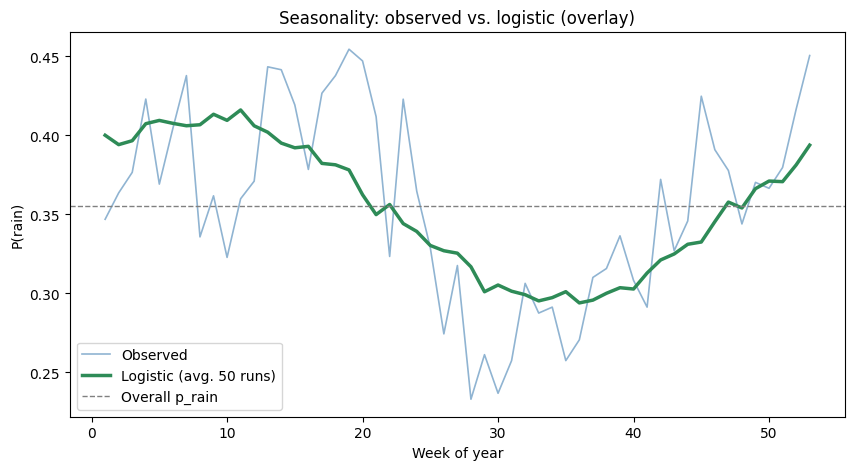

In [30]:
fig, ax = plt.subplots(figsize=(10, 5))

ax.plot(weekly_observed.index, weekly_observed.values, color='steelblue', linewidth=1.2, alpha=0.6, label='Observed')
ax.plot(weekly_logistic_avg.index, weekly_logistic_avg.values, color='seagreen', linewidth=2.5, label='Logistic (avg. 50 runs)')
ax.axhline(p_rain, color='gray', linestyle='--', linewidth=1, label='Overall p_rain')

ax.set_xlabel('Week of year')
ax.set_ylabel('P(rain)')
ax.set_title('Seasonality: observed vs. logistic (overlay)')
ax.legend()
plt.show()

In [31]:
data['sin_doy2'] = np.sin(4 * np.pi * data['doy'] / 365.25)
data['cos_doy2'] = np.cos(4 * np.pi * data['doy'] / 365.25)

model_data = data.dropna(subset=['rain_lag1'])

X2 = sm.add_constant(model_data[['rain_lag1', 'sin_doy', 'cos_doy', 'sin_doy2', 'cos_doy2']])
y = model_data['rain']

logit_model2 = sm.Logit(y, X2).fit()
print(logit_model2.summary())

Optimization terminated successfully.
         Current function value: 0.585688
         Iterations 5
                           Logit Regression Results                           
Dep. Variable:                   rain   No. Observations:                27908
Model:                          Logit   Df Residuals:                    27902
Method:                           MLE   Df Model:                            5
Date:                Tue, 15 Sep 2026   Pseudo R-squ.:                 0.09984
Time:                        13:41:28   Log-Likelihood:                -16345.
converged:                       True   LL-Null:                       -18158.
Covariance Type:            nonrobust   LLR p-value:                     0.000
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
const         -1.2086      0.018    -67.975      0.000      -1.243      -1.174
rain_lag1      1.5265      0.